# Lab 1 : Linear Regression

## G3 SDI - Machine Learning

In this lab, we are going to implement linear regression and ridge regression on a medical data example. The data come from a medical study (Stamey et al., 1989), whose goal was to predict the level of prostate-specific antigen (`lpsa`) from some clinical measurements. These clinical exams are carried out before a possible prostatectomy.

The measurements are log cancer volume `lcavol`, log prostate weight `lweight`, age of the patient `age`, log of benign prostatic hyperplasia amount `lbph`, seminal vesicle invasion `svi`, log of capsular penetration `lcp`, Gleason score `gleason`, and percent of Gleason scores 4 or 5 `pgg45`. The variable `svi` is binary, `gleason` is ordinal, others are quantitative.

### Instructions
* Rename your notebook with your surnames as `lab1_Name1_Name2.ipynb`, and include your names in the notebook.
* Your code, and its output, must be commented !
* Please upload your notebook on Moodle in the dedicated section before the deadline.

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Report written by FERNANDES--STRAG, TORRES--LEGUET, 25/09/26.
</div>

In [28]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

### Part 1 - Linear regression

In this first part, we focus on using linear regression.

**Q1.** Load the data from the `.npy` files included in the archive (use `np.load`). How many examples are there ? How many features ?

In [29]:
X = np.load("data_X.npy")
y = np.load("data_Y.npy")

print("taille de X", X.shape)
print("taille de Y", y.shape)

taille de X (97, 8)
taille de Y (97,)


In [30]:
print("-types de données:")
print("features:", X.dtype)
print("étiquettes:", y.dtype)
print()

# un échantillon
i = np.random.randint(0, X.shape[0])
print("-échantillon aléatoire tiré au hasard:")
print(X[i], y[i])
print()

print("-statistiques du dataset:")
print("moyenne de chaque features:", np.mean(X, axis=0))
print("moyenne des étiquettes:", np.mean(y))

-types de données:
features: float64
étiquettes: float64

-échantillon aléatoire tiré au hasard:
[ 1.44220199  3.68261    68.         -1.38629436  0.         -1.38629436
  7.         10.        ] 2.3075726

-statistiques du dataset:
moyenne de chaque features: [ 1.35000958  3.62894266 63.86597938  0.10035561  0.21649485 -0.17936558
  6.75257732 24.3814433 ]
moyenne des étiquettes: 2.478386878350515


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">

D"après la taille de la matrice $X$ qui est constituée en lignes de chaque example, il y a donc 97 exemples et 8 features. Le vecteur $y$ possède les 97 étiquettes de chacun des exemples.

Etant donné la nature des étiquettes qui sont des scalaires, on est bien sur un problème de régression.

D'après la description du dataset en consigne, les 8 features sont : lcavol, lweight, age, lbph, svi (binaire), lcp, gleason (ordinal/discret), pgg45.

On observe également les différences d'échelle entre les features, par exemple pgg45 est en pourcent (entre 0 et 100), l'age est en années (souvent supérieur à 50) alors que d'autres features sont beaucoup plus petites. Cela va donc nécessiter une normalisation.
</div>

**Q2.** Check whether there are some missing entries in the dataset (both in X and y). Use `np.isnan`.

In [31]:
nb_nan_X = np.sum(np.isnan(X)) # is nan = False (donc 0) ou True (donc 1), la somme nous donne donc le nombre de NaN
nb_nan_y = np.sum(np.isnan(y)) # idem sur les étiquettes

print("nombre de NaN dans X:", nb_nan_X)
print("nombre de NaN dans y:", nb_nan_y)

nombre de NaN dans X: 0
nombre de NaN dans y: 0


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Il n'y a aucune valeur manquante dans ce jeu de données.
</div>

**Q3.** Divide the dataset into a training set (80%) and a test set (20%), using `train_test_split` with `random_state = 0` (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)).

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print("-taille des données d'entraînement:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print()

print("-taille des données de test:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

-taille des données d'entraînement:
X_train: (77, 8)
y_train: (77,)

-taille des données de test:
X_test: (20, 8)
y_test: (20,)


D'après la documentation, `train_test_split` a pour convention sur $X$ que la dimension des exemples est la première, ce qui est bien notre cas. Cette fonction a aussi l'avantage d'effectuer un shuffle aléatoire des données avant le split, donc on écarte le risque d'avoir une distribution différente entre données d'entraînement et données de test.

On récupère bien environ 77 exemples dans le set d'entraînement, et 20 exemples dans le test set, ce qui correspond aux proportions 80%-20% sur 97 exemples.

**Q4.** Standardize the training set, and apply the same operation to the test set. Use `StandardScaler` (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)). Recall what standardization means.

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

print("-statistiques de normalisation sur le training set:")
print(scaler.mean_) # on obtient des valeurs un peu différentes de celles calculées sur l'ensemble du dataset, c'est attendu
print(scaler.var_)

# à ce stade, scaler a calculé moyenne et variance, on va l'appliquer sur les données d'entraînement et de test:
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

-statistiques de normalisation sur le training set:
[ 1.45797770e+00  3.63111404e+00  6.36103896e+01  6.21919622e-02
  2.46753247e-01 -1.20210145e-01  6.77922078e+00  2.40259740e+01]
[1.32534680e+00 1.87359887e-01 5.45495024e+01 2.05977571e+00
 1.85866082e-01 1.94384579e+00 5.87620172e-01 7.91609715e+02]


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
La normalisation consiste à mettre toutes les features du dataset à la même échelle (donc centrée sur la même valeur, 0, et ayant pour variance 1). L'intérêt est de pouvoir entraîner des poids qui ont le même ordre de grandeur, et donc éviter des instabilités numériques. Dans le cas de la ridge regression, c'est encore plus important car on utilise une pénalité de régularisation qui est la même pour tous les poids, donc il faut qu'ils aient la même échelle pour que cette pénalité s'applique avec la même "force".

Remarque : on note qu'il est important d'appliquer le scaler fité sur les données d'entraînement sur les données tests (et non un scaler fitté spécifiquement sur le test). Puisque que les paramètres appris/estimés sur scaler font partis en quelques sorte de notre modèle, si on voit de nouvelles données, on doit donc appliquer la même procédure qu'avec les données d'entraînement.
</div>

**Q5.** Compute the auto-covariance matrix from the training set, and display it (you might want to use `plt.imshow`). What can we learn from this ?

Text(0.5, 1.0, "Inter-corrélation des features (0-7) et corrélation des features avec l'étiquette (8)")

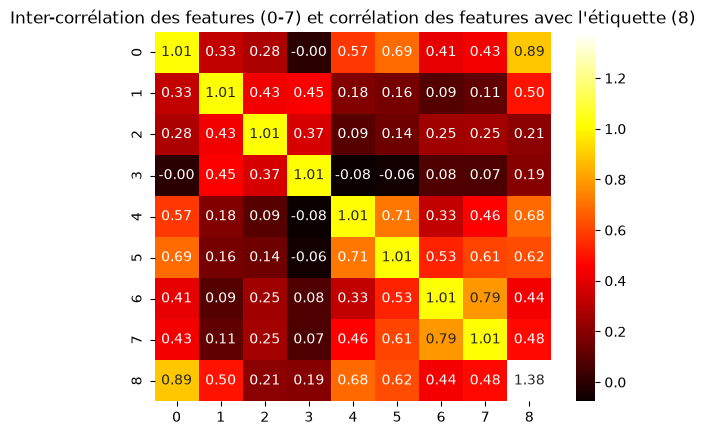

In [34]:
# autocorrélation des features + corrélation entre features et étiquettes

# pour l'auto-corrélation des features, comme X est normalisée, on peut utiliser
#sns.heatmap((X_train.T @ X_train)/X_train.shape[0], cmap='hot', annot=True, fmt=".2f")

# on peut aussi directement utiliser np.cov, en rajoutant y pour faire les deux en même temps (autocorrélation des features + corrélation entre features et étiquettes)
# à la main, on aurait aussi pu stacker X et y

sns.heatmap(np.cov(X_train.T, y=y_train), cmap='hot', annot=True, fmt=".2f")
#annot = true = on superpose les valeurs sur la heatmap
#fmt = formattage des flottants

plt.title("Inter-corrélation des features (0-7) et corrélation des features avec l'étiquette (8)")

# on utilise X.T et non X car np.cov attend pour variables les lignes, or nos variables (les features) sont en colonnes

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Note : la matrice obtenue est symétrique, car Cov(X,Y)=Cov(Y,X).

En analysant dans un premier temps seulement les features (donc en ométtant dernière ligne et dernière colonne), on remarque qu'aucune feature est parfaitement corrélées avec une autre. Le "pire" cas est une corrélation 0.8 entre gleason et pgg45, ce qui est attendu car pgg45 est construit sur gleason (c'est le % de gleason entre 4 et 5). Donc le problème de régression des moindres carré semble être bien posé et resolvable numériquement.

Concernant la corrélation entre chacune des features et étiquettes, on remarque que la première feature (lcavol) est fortement corrélée avec l'étiquette. On s'attend donc à ce que ce soit cette feature qui contribue le plus à la qualité de notre modèle. Au contraire, on pourrait enlever la feature 3 (lpbh) sans trop affecter les performances.
</div>

**Q6.** We are now going to train the linear regression model using scikit-learn (check the documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)). Use the `.fit` method on the training set. Retrieve the coefficients obtained by scikit-learn using the attributes `.intercept_` and `.coef_`, and check that it corresponds to the closed-form solution from the lecture (you might want to use `np.hstack` to concatenate X with a column of ones).

In [35]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression(fit_intercept=True) # s'occupe d'ajouter le biais / feature de valeur 1
reg.fit(X_train, y_train)

print("-coefficients du modèle de régression linéaire (sklearn):")
print("coefs:", reg.coef_)
print("norme des coefs:", np.linalg.norm(reg.coef_))
print("intercept:", reg.intercept_)

# à la main : (X^T X)^-1 X^T y
X_tilde = np.column_stack([np.ones(X_train.shape[0]), X_train]) # une feature de 1
theta = np.linalg.inv(X_tilde.T @ X_tilde) @ X_tilde.T @ y_train
# étant donné que les features ne X ne sont pas corrélées, l'inverse de X.T @ X est bien défini
print("-coefficients du modèle de régression linéaire (à la main):")
print("coefs:", theta[1:]) # [1:] = les betas associées aux "vraies" features
print("norme des coefs:", np.linalg.norm(theta[1:]))
print("intercept:", theta[0]) # [0] = le biais

-coefficients du modèle de régression linéaire (sklearn):
coefs: [ 0.76489178  0.21507901 -0.19817076  0.17007883  0.33767514 -0.2352964
  0.10599694  0.06116098]
norme des coefs: 0.9401498730858703
intercept: 2.5333575454545456
-coefficients du modèle de régression linéaire (à la main):
coefs: [ 0.76489178  0.21507901 -0.19817076  0.17007883  0.33767514 -0.2352964
  0.10599694  0.06116098]
norme des coefs: 0.9401498730858703
intercept: 2.5333575454545456


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">

Pour l'intercept, on retrouve une valeur proche de la moyenne des étiquettes calculée en Q1, ce qui est attendu car comme on l'a vu dans le cours, le problème de régression est équivalent au problème de regression où l'on soustrait la moyenne des étiquettes et se débarasser du biais.

On compare les résultats avec la formule analytique des moindres carrés : on obtient bien les mêmes coefficients (avec égalité au 8ème chiffre après la virgule!)

Remarque : on confirme l'effet de l'observation précédente dans la matrice d'auto-corrélation : le coefficient attaché à la première variable est le plus grand de tous (0.76).

</div>

**Q7.** Obtain the model predictions on the test set using the `.predict` method. Then compute the MSE and the MAE (you may want to use the functions below).

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = reg.predict(X_test) # vecteur des prédictions: (n_test,), ie un scalaire par échantillon de test

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("-erreurs sur le test set:")
print("MAE:", mae)
print("MSE:", mse)

mae_train = mean_absolute_error(y_train, reg.predict(X_train))
mse_train = mean_squared_error(y_train, reg.predict(X_train))

print("-erreurs sur le training set:")
print("MAE:", mae_train)
print("MSE:", mse_train)

-erreurs sur le test set:
MAE: 0.5645493769331605
MSE: 0.5401691943434794
-erreurs sur le training set:
MAE: 0.5012846288076077
MSE: 0.43654752179677325


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">

L'erreur sur le set d'entraînement est plus petite que sur le set de test, ce qui est attendu car les poids ont été modifiés pour bien prédire le set d'entraînement.

</div>

### Part 2 - Ridge regression

In this second part, we now turn to ridge regression.

**Q1.** Fit the ridge regression model (documentation [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html)) with $\lambda = 1$, using the `.fit` method on the training set. Again, retrieve the coefficients, and check that they match with the closed-form solution from the lecture. How do they differ from the ones obtained with linear regression ?

In [37]:
from sklearn.linear_model import Ridge

lambd = 1.

ridge = Ridge(alpha=lambd, fit_intercept=True)
ridge.fit(X_train, y_train)

print("-coefficients du modèle de régression Ridge (sklearn):")
print("coefs:", ridge.coef_)
print("norme des coefs:", np.linalg.norm(ridge.coef_))
print("intercept:", ridge.intercept_)

# à la main : (X^T X + alpha * I)^-1 X^T y
theta_ridge = np.linalg.inv(X_tilde.T @ X_tilde + lambd * np.eye(X_tilde.shape[1])) @ X_tilde.T @ y_train
print("-coefficients du modèle de régression Ridge (à la main):")
print("coefs:", theta_ridge[1:])
print("norme des coefs:", np.linalg.norm(theta_ridge[1:]))
print("intercept:", theta_ridge[0])

-coefficients du modèle de régression Ridge (sklearn):
coefs: [ 0.74219288  0.21604499 -0.18971641  0.16549832  0.32885721 -0.20975118
  0.102791    0.05942405]
norme des coefs: 0.9094765229262172
intercept: 2.5333575454545456
-coefficients du modèle de régression Ridge (à la main):
coefs: [ 0.74219288  0.21604499 -0.18971641  0.16549832  0.32885721 -0.20975118
  0.102791    0.05942405]
norme des coefs: 0.9094765229262166
intercept: 2.5008786025641028


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Comme dans le cas non régularisé, la solution trouvée par scikit est la même que celle calculée à la main.

On peut comparer la norme des paramètres appris par rapport au cas non régularisé, et on observe en effet que la norme est plus petite (0.94 contre 0.91). Plus on augmente alpha (c'est-à-dire le $\lambda$ du cours), plus la norme finale des poids appris diminue. Le cas limite $\lambda = +\inf$ reviendrait à ignorer le terme de fidélité des données et optimiser seulement la norme au carré, donc les poids obtenus seraient le vecteur nul.
</div>

**Q2.** Obtain the model predictions on the test set using the `.predict` method, then compute the MSE and the MAE. Do we get better or worse predictions than before ? Comment.

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = ridge.predict(X_test) # vecteur des prédictions: (n_test,), ie un scalaire par échantillon de test

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("-erreurs sur le test set:")
print("MAE:", mae)
print("MSE:", mse)

mae_train = mean_absolute_error(y_train, reg.predict(X_train))
mse_train = mean_squared_error(y_train, reg.predict(X_train))

print("-erreurs sur le training set:")
print("MAE:", mae_train)
print("MSE:", mse_train)

-erreurs sur le test set:
MAE: 0.5564065059757487
MSE: 0.5233533326725255
-erreurs sur le training set:
MAE: 0.5012846288076077
MSE: 0.43654752179677325


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Les prédictions du modèle régularisé sont en effet plus proches de la vérité que celles du modèle non régularisé sur le test de set, jamais vu pendant l'entraînement, puisque la MAE et MSE sont plus faibles.

Cela montre bien que l'effet souhaité par l'introduction de la régularisation a bien fonctionné : face à des données jamais vues, le modèle régularisé est meilleur que le modèle non régularisé. On a diminué le sur-apprentissage, ie, le modèle est moins en mesure d'apprendre la particularité des données, mais davantage la loi fondamentale. Autrement dit, on a réduit la variance de notre modèle (par rapport aux données). On se rapproche du compromis optimal biais-variance.
</div>

**Q3.** We are now going to assess the impact of the regularization coefficient $\lambda$.

To do so, vary $\lambda$ from $10^{-3}$ and $10^3$ (use `np.logspace`), and for each value of $\lambda$, retrain the ridge regression model and keep the values of the coefficients (ignoring the intercept).

Display the evolution of the coefficients w.r.t. $\lambda$ (use a logarithmic scale for the x-axis). Comment.

In [45]:
lambdas = np.logspace(-3, 3, 30)
norms = []
params = np.zeros((8, len(lambdas)))

for i, lambd in enumerate(lambdas):
    ridge = Ridge(alpha=lambd, fit_intercept=True)
    ridge.fit(X_train, y_train)
    norms.append(np.linalg.norm(ridge.coef_))
    params[:, i] = ridge.coef_

y_pred = ridge.predict(X_test) # vecteur des prédictions: (n_test,), ie un scalaire par échantillon de test

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Métrique du modèle entraîné avec le lambda le plus fort:")
print(mae, mse)

Métrique du modèle entraîné avec le lambda le plus fort:
0.7823697350572896 0.9169809405876391


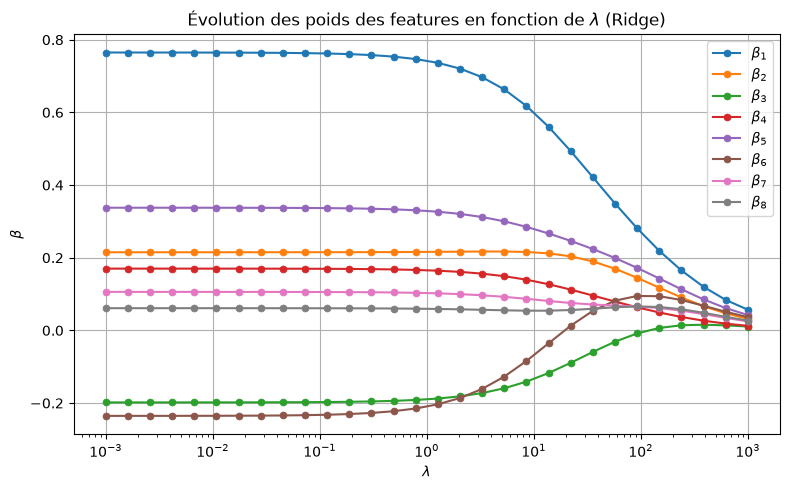

In [56]:
# on affiche l'évolution des poids des 8 features à mesure que lambda augmente
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(params.shape[0]):
    ax.plot(lambdas, params[i, :], linewidth=1.5, marker="o",
            markersize=5, markeredgewidth=0.5, label=rf"$\beta_{i+1}$")

ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\beta$")
ax.set_title(r"Évolution des poids des features en fonction de $\lambda$ (Ridge)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Pourcentage de coefficients nuls dans la régression Lasso en fonction de lambda')

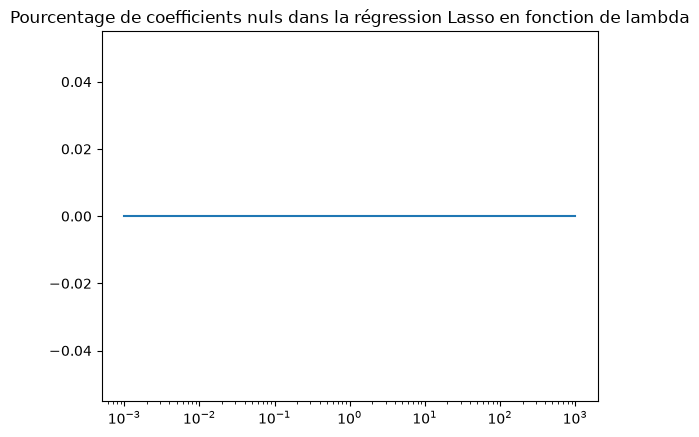

In [49]:
prct_nul = np.sum(params == 0, axis=0) / len(lambdas) * 100

plt.plot(lambdas, prct_nul)
plt.xscale('log')
plt.title("Pourcentage de coefficients nuls dans la régression Lasso en fonction de lambda")

Text(0.5, 1.0, 'Norme des poids appris dans la régression ridge en fonction de lambda')

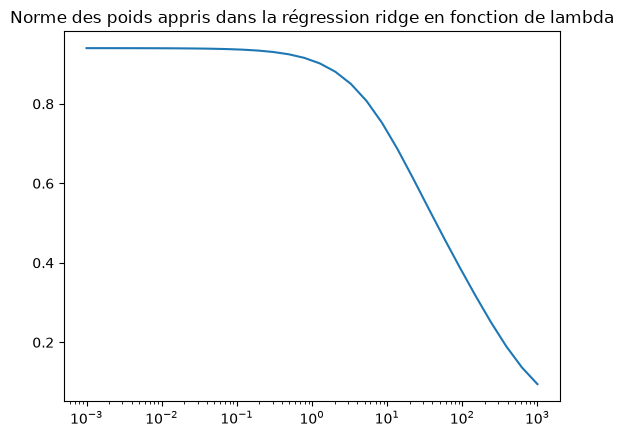

In [50]:
# on affiche aussi la norme des poids appris en fonction de lambda
plt.plot(lambdas, norms)
plt.xscale('log')
plt.title("Norme des poids appris dans la régression ridge en fonction de lambda")

<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
On utilise deux visualisation pour observer comment évoluent les poids :

**Visualisation des poids** Comme le problème le permet, on visualise l'évolution des poids en fonction du coefficient de régularisation. Globalement, on retrouve la convergence des poids vers 0. A mesure que lambda augmente, le modèle arrête d'utiliser un poids très fort pour la feature 0 (qu'on sait fortement corrélés avec la sortie à prédire) et régule sa prédiction avec les autres variables. En mesure annexe, on regarde pour chaque lambda, le pourcentage de poids mis exactement à 0, et il reste nul dans ce cas (résultat qu'on va comparer au cas Lasso). beta_1 est davantage réduit en proportion car sa valeur initiale(sans régularisation) est la plus grande : la pénalité du terme de régularisation frappe d'autant plus fort les coefficients de grande amplitude pour permettre une meilleure stabilité du modèle.

**Norme des poids**
Comme discuté plus haut, augmenter $\lambda$ entraîne la réduction des normes des poids appris, c'est-à-dire que les poids appris se rapprochent de plus en plus du vecteur nul.

Evidemment, il y a un optimal à trouver car le modèle entraîné avec $\lambda=10^3$ est mauvais, même sur les données de test (cf ses métriques).
</div>

**Q4.** Now remains the question of choosing the optimal $\lambda$. We are going to select it with a 5-fold cross-validation.

Display the evolution of the cross-validated MSE w.r.t. $\lambda$ (use again a logarithmic scale for the x-axis), and display the best $\lambda$ with a `plt.axvline`.

Now retrain the ridge regression model with the selected $\lambda$, and assess its performance in terms of MSE and MAE. Comment.

In [17]:
from sklearn.model_selection import KFold

# Set-up cross-validation
kf = KFold(n_splits=5)

lambdas = np.logspace(-3, 3, 30)
mse_moyennes = []

for i, lambd in enumerate(lambdas):

    mses = []

    for train_index, val_index in kf.split(X_train):
        X_train_new, X_val = X_train[train_index], X_train[val_index]
        y_train_new, y_val = y_train[train_index], y_train[val_index]
        
        ridge = Ridge(alpha=lambd, fit_intercept=True)
        ridge.fit(X_train_new, y_train_new)

        y_pred = ridge.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred)
        mse = mean_squared_error(y_val, y_pred)

        mses.append(mse)

    mse_moyenne = np.mean(mses)
    mse_moyennes.append(mse_moyenne)

best_idx = np.argmin(mse_moyennes)
best_lambda = lambdas[best_idx]

Text(0.5, 1.0, 'Evolution de la MSE en fonction de $\\lambda$')

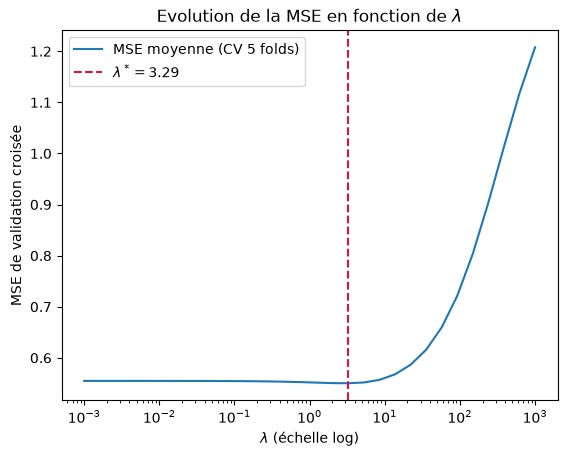

In [18]:
plt.plot(lambdas, mse_moyennes, label="MSE moyenne (CV 5 folds)")
plt.axvline(best_lambda, color="crimson", ls="--", label=fr"$\lambda^* = {best_lambda:.3g}$")

plt.xscale('log')
plt.xlabel(r"$\lambda$ (échelle log)")
plt.ylabel("MSE de validation croisée")
plt.legend()
plt.title(r"Evolution de la MSE en fonction de $\lambda$")

In [19]:
ridge = Ridge(alpha=best_lambda, fit_intercept=True)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("-erreurs sur le test set avec le meilleur lambda:")
print("MAE:", mae)
print("MSE:", mse)

-erreurs sur le test set avec le meilleur lambda:
MAE: 0.5421897175325563
MSE: 0.4931145047224361


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">
Les métriques d'évaluation sur le set de test sont meilleures que celles obtenus en Q2 (MAE: 0.5497943828080365, MSE: 0.5089040781263021), elles mêmes étant meilleures que la version non régularisée. On a obtenu une meilleure performance sur le set de test sans pour autant optimiser lambda sur ce test en particulier, donc il y a de bonnes chances que le lambda trouvé soit en effet plus proche du "vrai" lambda optimal de ce problème.
</div>

### Part 3 (Bonus) - LASSO

Display the same kind of plots as in Part 2, but using LASSO regression instead of ridge regression (see [here](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html). In particular, comment on the following points :
* Do the regression coefficients evolve in the same way as ridge regression ? What kind of solutions do we obtain ?
* Do we get the same optimal lambda ?

In [58]:
from sklearn.linear_model import Lasso

lambdas = np.logspace(-3, 3, 30)
norms = []
params = np.zeros((8, len(lambdas)))

for i, lambd in enumerate(lambdas):
    ridge = Lasso(alpha=lambd, fit_intercept=True)
    ridge.fit(X_train, y_train)
    norms.append(np.linalg.norm(ridge.coef_))
    params[:, i] = ridge.coef_

y_pred = ridge.predict(X_test) # vecteur des prédictions: (n_test,), ie un scalaire par échantillon de test

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print("Métrique du modèle entraîné avec le lambda le plus fort:")
print(mae, mse)

Métrique du modèle entraîné avec le lambda le plus fort:
0.8936908099999998 1.1557729200090008


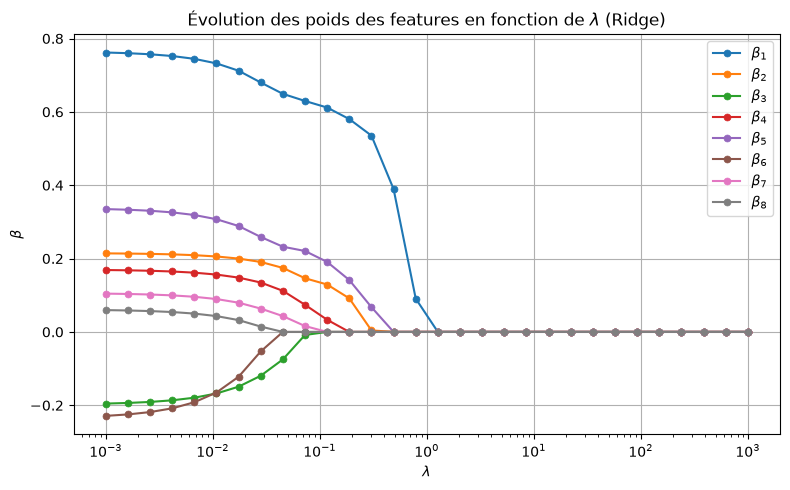

In [59]:
# on affiche l'évolution des poids des 8 features à mesure que lambda augmente
fig, ax = plt.subplots(figsize=(8, 5))

for i in range(params.shape[0]):
    ax.plot(lambdas, params[i, :], linewidth=1.5, marker="o",
            markersize=5, markeredgewidth=0.5, label=rf"$\beta_{i+1}$")

ax.set_xscale("log")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"$\beta$")
ax.set_title(r"Évolution des poids des features en fonction de $\lambda$ (Ridge)")
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Pourcentage de coefficients nuls dans la régression Lasso en fonction de lambda')

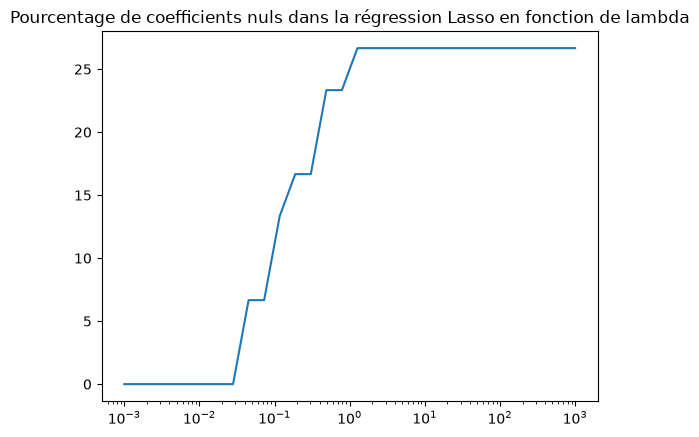

In [60]:
prct_nul = np.sum(params == 0, axis=0) / len(lambdas) * 100

plt.plot(lambdas, prct_nul)
plt.xscale('log')
plt.title("Pourcentage de coefficients nuls dans la régression Lasso en fonction de lambda")

Text(0.5, 1.0, 'Norme des poids appris dans la régression ridge en fonction de lambda')

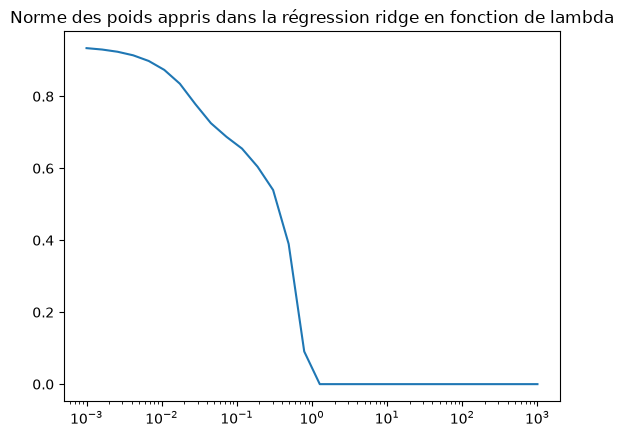

In [61]:
plt.plot(lambdas, norms)
plt.xscale('log')
plt.title("Norme des poids appris dans la régression ridge en fonction de lambda")

In [24]:
# Set-up cross-validation
kf = KFold(n_splits=5)

lambdas = np.logspace(-3, 3, 30)
mse_moyennes = []

for i, lambd in enumerate(lambdas):

    mses = []

    for train_index, val_index in kf.split(X_train):
        X_train_new, X_val = X_train[train_index], X_train[val_index]
        y_train_new, y_val = y_train[train_index], y_train[val_index]
        
        ridge = Lasso(alpha=lambd, fit_intercept=True)
        ridge.fit(X_train_new, y_train_new)

        y_pred = ridge.predict(X_val)

        mae = mean_absolute_error(y_val, y_pred)
        mse = mean_squared_error(y_val, y_pred)

        mses.append(mse)

    mse_moyenne = np.mean(mses)
    mse_moyennes.append(mse_moyenne)

best_idx = np.argmin(mse_moyennes)
best_lambda = lambdas[best_idx]

Text(0.5, 1.0, 'Evolution de la MSE en fonction de $\\lambda$')

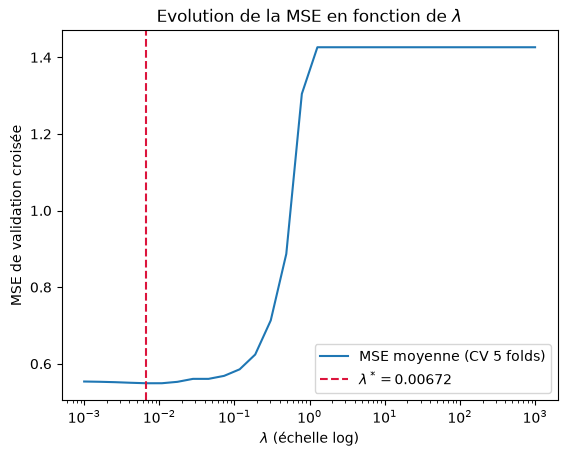

In [25]:
plt.plot(lambdas, mse_moyennes, label="MSE moyenne (CV 5 folds)")
plt.axvline(best_lambda, color="crimson", ls="--", label=fr"$\lambda^* = {best_lambda:.3g}$")

plt.xscale('log')
plt.xlabel(r"$\lambda$ (échelle log)")
plt.ylabel("MSE de validation croisée")
plt.legend()
plt.title(r"Evolution de la MSE en fonction de $\lambda$")

In [26]:
ridge = Lasso(alpha=best_lambda, fit_intercept=True)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("-erreurs sur le test set avec le meilleur lambda:")
print("MAE:", mae)
print("MSE:", mse)

-erreurs sur le test set avec le meilleur lambda:
MAE: 0.554887685091018
MSE: 0.5226298490413683


<div style="background-color: rgba(255, 255, 0, 0.15); padding: 8px;">

L'évolution des poids en fonction de $\lambda$ (premier graphique) montre que la régularisation Lasso (donc en norme 1) est plus aggressive et fait tomber les poids vers 0 plus rapidement. Cela est confirmé par la recherche du $\lambda$ optimal en validation 5-fold, qui vaut 6.7e-3 dans le cas Lasso contre 3.29 pour Ridge.
Pour ce problème, la régression Ridge donne de meilleurs résultats que Lasso (Ridge : MSE 0.493, Lasso : MSE 0.523). Cela peut s'expliquer par le fait que dans notre cas, sans régularisation, seulement deux coefficients dominent la régression. Le lasso, qui tend à annuler les coefficients les plus faibles, ne peut qu'augmenter la MSE s'il se met à annuler des coefficients importants, d'où la croissance subite dès que le lambda devient un minimum conséquent (0.1). Cette méthode de régularisation privéligie la simplicité du modèle, au détriment du biais.

Enfin, on analyse la norme des poids finaux en fonction de $\lambda$, et, contrairement à Ridge, on s'aperçoit que pour un coefficient de régularisation autour de 1, la régression Lasso commence à produire des poids qui valent exactement le vecteur nul, d'où l'idée de sparsité évoquée en cours (qu'on n'observe pas dans le cas Ridge). Un graphique similaire qui montre le pourcentage des poids nuls montre aussi ce phénomène de sparsité des poids dans un modèle Lasso.

</div>